# TB-DOTS CAR CDSS — Hybrid Bi-LSTM Treatment Outcome Prediction

**Bidirectional LSTM + Masked Attention + Static FC** for predicting TB treatment outcome (**Success / Failure**) with confidence scores, using monthly patient monitoring data and baseline clinical features.

This notebook trains **two variants** of the Bi-LSTM model:
1. **Baseline** — standard BCE loss, no augmentation
2. **Augmented** — Gaussian noise injection + Mixup + Focal Loss + threshold optimization

Both variants are compared on the same held-out test set to quantify the impact of data augmentation on class imbalance handling.

### Architecture
- **Temporal branch**: Bidirectional LSTM (packed sequences) → Masked Soft Attention
- **Static branch**: Feed-forward network (51 baseline features → 32-dim)
- **Fusion**: Concatenate temporal + static → FC → Sigmoid

### Data Augmentation & Class Imbalance Handling (Augmented variant)
- **Gaussian noise injection** — 5 noisy copies per minority patient (std=0.05)
- **Mixup** — Beta(0.4, 0.4) interpolation between minority patient pairs
- **Focal Loss** (alpha=0.75, gamma=2.0) — down-weights easy examples
- **WeightedRandomSampler** — balanced mini-batches during training
- **Threshold optimization** — validation-set search for optimal threshold

### Outputs
- Trained model checkpoints → `models/Temporal/output/hybrid_lstm/best_model.pt`, `models/Temporal/output/hybrid_lstm/baseline_model.pt`
- Evaluation metrics → `models/Temporal/output/hybrid_lstm/evaluation_report.txt`
- Per-patient predictions → `models/Temporal/output/hybrid_lstm/predictions.csv`
- Baseline vs Augmented comparison → `models/Temporal/output/hybrid_lstm/per_month_performance.png`


## 0. Imports & Configuration

In [12]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)

warnings.filterwarnings("ignore")

# ── Reproducibility ─────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Paths ───────────────────────────────────────────────────────
REPO_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents]
     if (p / "dataset").exists() and (p / "models").exists()),
    Path.cwd(),
)
BASE_DIR = REPO_ROOT
DATA_DIR = REPO_ROOT / "dataset" / "temporal"
MODEL_DIR = REPO_ROOT / "models" / "Temporal" / "v2" / "output" / "hybrid_lstm"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"Data   : {DATA_DIR}")
print(f"Models : {MODEL_DIR}")


Device : cpu
PyTorch: 2.9.1+cpu
Data   : c:\Users\Ven\Documents\Thesis\TB-DOTS-CAR-CDSS\dataset\temporal
Models : c:\Users\Ven\Documents\Thesis\TB-DOTS-CAR-CDSS\models\Temporal\v2\output\hybrid_lstm


## 1. Data Loading & Label Creation

Load the preprocessed temporal and static arrays from the preprocessing pipeline. The **outcome** columns are removed from static features to prevent target leakage. Binary labels are created:
- **Success (1)** = Cured, Treatment Completed
- **Failure (0)** = Died, Lost to Follow-Up, Not Evaluated

In [13]:
def load_data():
    """Load harmonized temporal data with trustworthy train-fit transforms."""
    import sys
    sys.path.append(str(BASE_DIR / "models" / "Temporal"))
    import model_utils as mu

    csv_path = DATA_DIR / "combined_complete_dataset.csv"
    model_data = mu.prepare_default_model_inputs(
        str(csv_path),
        train_frac=0.70,
        val_frac=0.20,
        test_frac=0.10,
        random_state=SEED,
        drop_feature_cols=mu.get_temporal_v2_drop_feature_cols(),
    )

    X_temporal = model_data["X_temporal"]
    X_static = model_data["X_static"]
    y = model_data["y"]
    static_names = list(model_data["static_feature_names"])
    train_idx = model_data["train_idx"]
    val_idx = model_data["val_idx"]
    test_idx = model_data["test_idx"]
    df = model_data["df"]
    global FEATURE_POLICY_VERSION, DROPPED_FEATURE_COLS, STATIC_MNAR_INDICATORS, TEMPORAL_MNAR_INDICATORS, TEMPORAL_FEATURE_NAMES
    FEATURE_POLICY_VERSION = model_data.get("feature_policy_version", "custom")
    DROPPED_FEATURE_COLS = model_data.get("dropped_feature_cols", [])
    STATIC_MNAR_INDICATORS = model_data.get("static_missing_indicator_names", [])
    TEMPORAL_MNAR_INDICATORS = model_data.get("temporal_missing_indicator_names", [])
    TEMPORAL_FEATURE_NAMES = list(model_data["temporal_feature_names"])

    print(f"Temporal features : {X_temporal.shape}")
    print(f"Static features   : {X_static.shape}  (leakage-controlled + MNAR-aware)")
    print(f"Feature policy    : {model_data.get('feature_policy_version', 'custom')}")
    print(f"Dropped features  : {model_data.get('dropped_feature_cols', [])}")
    print(f"Static MNAR flags : {len(model_data.get('static_missing_indicator_names', []))}")
    print(f"Temporal MNAR flags: {len(model_data.get('temporal_missing_indicator_names', []))}")
    print(f"Labels            : {y.shape}  (Success={int(y.sum())}, Failure={int(len(y) - y.sum())})")
    print(f"Split sizes       : train={len(train_idx)}, val={len(val_idx)}, test={len(test_idx)}")

    return X_temporal, X_static, y, static_names, df, train_idx, val_idx, test_idx

X_temporal, X_static, y, static_names, df, train_idx, val_idx, test_idx = load_data()


STAGE 3: Data Cleaning & Type Coercion
  Parsed 'date_of_birth': 573/599 valid, 26 filled with median (1975-10-23)
  Parsed 'date_of_diagnosis': 477/599 valid, 122 filled with median (2023-08-29)
  Parsed 'date_of_notification': 432/599 valid, 167 filled with median (2023-09-23)
  Parsed 'treatment_start_date': 541/599 valid, 58 filled with median (2023-08-19)
  Parsed 'date_of_outcome': 355/599 valid, 244 filled with median (2023-12-03)
  Parsed 'intensive_phase_start_date': 461/599 valid, 138 filled with median (2023-10-11)
  Parsed 'intensive_phase_end_date': 381/599 valid, 218 filled with median (2023-12-08)
  Parsed 'continuation_phase_start_date': 359/599 valid, 240 filled with median (2023-12-09)
  Parsed 'continuation_phase_end_date': 367/599 valid, 232 filled with median (2024-03-21)
  Fixed 1 future DOBs by subtracting 100 years
  Fixed 2 historically implausible DOBs (pre-1920) by adding 100 years
  Fixed 29 future dates in 'date_of_diagnosis' by subtracting 10 years
  Fixed

In [14]:
import sys
sys.path.insert(0, str(BASE_DIR / "models" / "Temporal"))
import model_utils as mu

# Fit scalers on the precomputed training split only and transform the full arrays.
scaled = mu.scale_full_arrays(X_static, X_temporal, train_idx)
X_static = scaled["X_static_scaled"]
X_temporal = scaled["X_temporal_scaled"]
mu.save_scalers(scaled["scaler_static"], scaled["scaler_temporal"], str(DATA_DIR))

print(f"Scaled arrays: X_temporal={X_temporal.shape}, X_static={X_static.shape}")
print(f"Split sizes: train={len(train_idx)}, val={len(val_idx)}, test={len(test_idx)}")


Scaled arrays: X_temporal=(431, 13, 16), X_static=(431, 98)
Split sizes: train=301, val=86, test=44


In [15]:
def augment_minority_patients(X_temporal, X_static, y,
                              n_noise_copies=5, noise_std=0.05,
                              n_mixup_pairs=None, seed=42):
    """
    Augment minority class (Failure=0) patients at the PATIENT level.

    Strategies:
      1. Gaussian noise injection: create `n_noise_copies` noisy copies
         of each minority patient (temporal + static features).
      2. Mixup: interpolate between random pairs of minority patients
         using Beta(0.4, 0.4) distribution for diverse combinations.

    Parameters
    ----------
    X_temporal : (N, 13, 8) temporal features
    X_static   : (N, 51) static features
    y          : (N,) binary labels (1=Success, 0=Failure)
    n_noise_copies : int, number of noisy copies per minority patient
    noise_std  : float, std of Gaussian noise (relative to feature scale)
    n_mixup_pairs : int or None, number of mixup pairs (default: 2× minority count)
    seed       : int, random seed

    Returns
    -------
    X_temporal_aug, X_static_aug, y_aug : augmented arrays
    """
    rng = np.random.RandomState(seed)

    minority_mask = (y == 0)  # Failure class
    X_temp_min = X_temporal[minority_mask]
    X_stat_min = X_static[minority_mask]
    n_minority = int(minority_mask.sum())

    if n_mixup_pairs is None:
        n_mixup_pairs = n_minority * 2

    aug_temporal = []
    aug_static = []
    aug_y = []

    # ── Strategy 1: Gaussian noise injection ────────────────────
    for _ in range(n_noise_copies):
        for i in range(n_minority):
            noise_t = rng.normal(0, noise_std, X_temp_min[i].shape).astype(np.float32)
            noise_s = rng.normal(0, noise_std * 0.5, X_stat_min[i].shape).astype(np.float32)

            aug_temporal.append(X_temp_min[i] + noise_t)
            aug_static.append(X_stat_min[i] + noise_s)
            aug_y.append(0.0)

    # ── Strategy 2: Mixup between minority patient pairs ────────
    if n_minority >= 2:
        for _ in range(n_mixup_pairs):
            i, j = rng.choice(n_minority, size=2, replace=False)
            lam = rng.beta(0.4, 0.4)  # U-shaped → mostly near 0 or 1
            aug_temporal.append(
                (lam * X_temp_min[i] + (1 - lam) * X_temp_min[j]).astype(np.float32)
            )
            aug_static.append(
                (lam * X_stat_min[i] + (1 - lam) * X_stat_min[j]).astype(np.float32)
            )
            aug_y.append(0.0)

    # ── Combine original + augmented ────────────────────────────
    X_temporal_aug = np.concatenate(
        [X_temporal, np.array(aug_temporal, dtype=np.float32)]
    )
    X_static_aug = np.concatenate(
        [X_static, np.array(aug_static, dtype=np.float32)]
    )
    y_aug = np.concatenate([y, np.array(aug_y, dtype=np.float32)])

    n_new = len(aug_y)
    n_total = len(y_aug)
    n_fail_after = int((y_aug == 0).sum())
    n_success_after = int((y_aug == 1).sum())

    print(f"Augmentation results:")
    print(f"  Original minority (Failure): {n_minority} patients")
    print(f"  Noise copies: {n_noise_copies} × {n_minority} = {n_noise_copies * n_minority}")
    print(f"  Mixup pairs:  {n_mixup_pairs}")
    print(f"  Total new synthetic patients: {n_new}")
    print(f"  Final dataset: {n_total} patients "
          f"(Success={n_success_after}, Failure={n_fail_after})")
    print(f"  Class ratio: {n_fail_after / n_total * 100:.1f}% Failure "
          f"(was {n_minority / len(y) * 100:.1f}%)")

    return X_temporal_aug, X_static_aug, y_aug

In [16]:
class TBProgressiveDataset(Dataset):
    """
    Progressive temporal dataset for CDSS training.

    For each patient, creates one sample per month t (0..max_month):
      - Temporal input: months 0..t (rest zero-padded to 13 steps)
      - Sequence length: t + 1  (how many months are valid)
      - Static features: same across all months
      - Label: final treatment outcome (same across all months)

    This teaches the model to predict from partial sequences,
    which is exactly what a CDSS does in real-time.
    """

    def __init__(self, X_temporal, X_static, y,
                 min_month=0, max_month=12):
        self.X_temporal_list = []
        self.seq_lens = []
        self.X_static_list = []
        self.y_list = []

        for i in range(len(y)):
            for t in range(min_month, max_month + 1):
                # Zero-pad future months
                x_t = np.zeros_like(X_temporal[i])
                x_t[: t + 1] = X_temporal[i, : t + 1]

                self.X_temporal_list.append(x_t)
                self.seq_lens.append(t + 1)
                self.X_static_list.append(X_static[i])
                self.y_list.append(y[i])

        self.X_temporal_arr = np.array(self.X_temporal_list, dtype=np.float32)
        self.seq_lens_arr = np.array(self.seq_lens, dtype=np.int64)
        self.X_static_arr = np.array(self.X_static_list, dtype=np.float32)
        self.y_arr = np.array(self.y_list, dtype=np.float32)

    def __len__(self):
        return len(self.y_arr)

    def __getitem__(self, idx):
        return (
            torch.FloatTensor(self.X_temporal_arr[idx]),
            torch.LongTensor([self.seq_lens_arr[idx]]),
            torch.FloatTensor(self.X_static_arr[idx]),
            torch.FloatTensor([self.y_arr[idx]]),
        )

def build_dataloaders(X_temporal, X_static, y, train_idx, val_idx, test_idx,
                      batch_size=32, augment=True, n_noise_copies=5, noise_std=0.05):
    """Use the precomputed patient-level split, optionally augment training patients,
    then expand into progressive sequences."""
    y_train_patients = y[train_idx]
    y_val_patients = y[val_idx]
    y_test_patients = y[test_idx]

    print(f"Patient split:")
    print(f"  Train : {len(train_idx)} patients  "
          f"(S={int(y_train_patients.sum())}, "
          f"F={int(len(y_train_patients) - y_train_patients.sum())})")
    print(f"  Val   : {len(val_idx)} patients  "
          f"(S={int(y_val_patients.sum())}, "
          f"F={int(len(y_val_patients) - y_val_patients.sum())})")
    print(f"  Test  : {len(test_idx)} patients  "
          f"(S={int(y_test_patients.sum())}, "
          f"F={int(len(y_test_patients) - y_test_patients.sum())})")

    X_temporal_train = X_temporal[train_idx]
    X_static_train = X_static[train_idx]
    y_train_raw = y[train_idx]

    if augment:
        print(f"\nApplying data augmentation on training patients...")
        X_temporal_train, X_static_train, y_train_raw = augment_minority_patients(
            X_temporal_train, X_static_train, y_train_raw,
            n_noise_copies=n_noise_copies,
            noise_std=noise_std,
            seed=SEED,
        )

    train_ds = TBProgressiveDataset(
        X_temporal_train, X_static_train, y_train_raw,
        min_month=0, max_month=12,
    )
    val_ds = TBProgressiveDataset(
        X_temporal[val_idx], X_static[val_idx], y[val_idx],
        min_month=0, max_month=12,
    )
    test_ds = TBProgressiveDataset(
        X_temporal[test_idx], X_static[test_idx], y[test_idx],
        min_month=12, max_month=12,
    )

    n_train_patients = len(y_train_raw)
    print(f"\nProgressive samples:")
    print(f"  Train : {len(train_ds)} samples  "
          f"({n_train_patients} patients x 13 months)")
    print(f"  Val   : {len(val_ds)} samples  ({len(val_idx)} patients x 13 months)")
    print(f"  Test  : {len(test_ds)} samples  ({len(test_idx)} patients x 1 full seq)")

    class_counts = np.bincount(train_ds.y_arr.astype(int))
    class_weights = 1.0 / class_counts
    sample_weights = np.array(
        [class_weights[int(label)] for label in train_ds.y_arr]
    )
    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(train_ds),
        replacement=True,
    )

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, sampler=sampler, drop_last=True
    )
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return (train_loader, val_loader, test_loader,
            y_train_patients, y_test_patients,
            train_idx, val_idx, test_idx)

(train_loader, val_loader, test_loader,
 y_train, y_test,
 train_idx, val_idx, test_idx) = build_dataloaders(
    X_temporal, X_static, y, train_idx, val_idx, test_idx,
    batch_size=32,
    augment=True, n_noise_copies=5, noise_std=0.05,
 )


Patient split:
  Train : 301 patients  (S=257, F=44)
  Val   : 86 patients  (S=73, F=13)
  Test  : 44 patients  (S=38, F=6)

Applying data augmentation on training patients...
Augmentation results:
  Original minority (Failure): 44 patients
  Noise copies: 5 × 44 = 220
  Mixup pairs:  88
  Total new synthetic patients: 308
  Final dataset: 609 patients (Success=257, Failure=352)
  Class ratio: 57.8% Failure (was 14.6%)

Progressive samples:
  Train : 7917 samples  (609 patients x 13 months)
  Val   : 1118 samples  (86 patients x 13 months)
  Test  : 44 samples  (44 patients x 1 full seq)


In [17]:
class TemporalAttention(nn.Module):
    """Soft attention over LSTM time-step outputs with optional masking."""

    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1, bias=False),
        )

    def forward(self, lstm_out, seq_lens=None):
        # lstm_out: (batch, seq_len, hidden_size)
        scores = self.attn(lstm_out).squeeze(-1)           # (batch, seq_len)

        # Mask future (zero-padded) months so attention ignores them
        if seq_lens is not None:
            max_len = lstm_out.size(1)
            # mask[b, t] = True if t >= seq_lens[b]  (i.e., invalid)
            time_idx = torch.arange(max_len, device=lstm_out.device).unsqueeze(0)
            mask = time_idx >= seq_lens.unsqueeze(1)       # (batch, seq_len)
            scores = scores.masked_fill(mask, float("-inf"))

        weights = torch.softmax(scores, dim=1)             # (batch, seq_len)
        context = torch.bmm(weights.unsqueeze(1),
                            lstm_out).squeeze(1)           # (batch, hidden_size)
        return context, weights


class TB_LSTM_CDSS(nn.Module):
    """
    Hybrid model for TB treatment outcome prediction.

    Temporal branch : Bidirectional LSTM (packed sequences) + Masked Attention
    Static branch   : Feed-forward network
    Fusion          : Concatenate → FC → Sigmoid

    Accepts `seq_lens` so it can be trained on progressive
    partial sequences and used as a real-time CDSS.
    """

    def __init__(
        self,
        temporal_features: int = 8,
        static_features: int = 51,
        lstm_hidden: int = 64,
        lstm_layers: int = 2,
        dropout: float = 0.3,
    ):
        super().__init__()

        # ── Temporal branch ──────────────────────────────────────
        self.lstm = nn.LSTM(
            input_size=temporal_features,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )
        self.temporal_attention = TemporalAttention(lstm_hidden * 2)
        self.temporal_norm = nn.LayerNorm(lstm_hidden * 2)

        # ── Static branch ────────────────────────────────────────
        self.static_net = nn.Sequential(
            nn.Linear(static_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # ── Fusion + classifier ──────────────────────────────────
        fusion_dim = lstm_hidden * 2 + 32
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x_temporal, x_static, seq_lens=None):
        # ── Temporal: pack → LSTM → unpack → masked attention ──
        if seq_lens is not None:
            packed = nn.utils.rnn.pack_padded_sequence(
                x_temporal,
                seq_lens.cpu().clamp(min=1),
                batch_first=True,
                enforce_sorted=False,
            )
            packed_out, _ = self.lstm(packed)
            lstm_out, _ = nn.utils.rnn.pad_packed_sequence(
                packed_out, batch_first=True,
                total_length=x_temporal.size(1),
            )
        else:
            lstm_out, _ = self.lstm(x_temporal)

        context, attn_weights = self.temporal_attention(lstm_out, seq_lens)
        context = self.temporal_norm(context)               # (B, H*2)

        # ── Static ───────────────────────────────────────────────
        static_repr = self.static_net(x_static)            # (B, 32)

        # ── Fuse ─────────────────────────────────────────────────
        fused = torch.cat([context, static_repr], dim=1)   # (B, H*2+32)
        logit = self.classifier(fused).squeeze(-1)         # (B,)
        return logit, attn_weights


# Display model architecture (using a temporary model instance)
_tmp_model = TB_LSTM_CDSS(
    temporal_features=X_temporal.shape[2],
    static_features=X_static.shape[1],
    lstm_hidden=64, lstm_layers=2, dropout=0.3,
)
total_params = sum(p.numel() for p in _tmp_model.parameters())
trainable = sum(p.numel() for p in _tmp_model.parameters() if p.requires_grad)
print(f"Parameters: {total_params:,} total, {trainable:,} trainable")
print(f"\n{_tmp_model}")
del _tmp_model

Parameters: 171,041 total, 171,041 trainable

TB_LSTM_CDSS(
  (lstm): LSTM(16, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (temporal_attention): TemporalAttention(
    (attn): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=1, bias=False)
    )
  )
  (temporal_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (static_net): Sequential(
    (0): Linear(in_features=98, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=160, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1

In [18]:
class FocalLoss(nn.Module):
    """
    Focal Loss for binary classification (Lin et al., 2017).
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)
        p_t = torch.where(targets == 1, probs, 1 - probs)
        alpha_t = torch.where(targets == 1, self.alpha, 1 - self.alpha)
        focal_weight = alpha_t * (1 - p_t) ** self.gamma
        loss = focal_weight * bce
        return loss.mean()


def train_model(model, train_loader, val_loader, y_train,
                epochs=150, lr=1e-3, patience=20,
                use_focal_loss=True, save_path="best_model.pt"):
    """
    Train with early stopping and LR scheduling.
    If use_focal_loss=True, uses Focal Loss; otherwise standard BCE.
    """
    if use_focal_loss:
        criterion = FocalLoss(alpha=0.75, gamma=2.0)
        print("Loss: Focal Loss (alpha=0.75, gamma=2.0)")
    else:
        # Weighted BCE for baseline
        n_pos = y_train.sum()
        n_neg = len(y_train) - n_pos
        pos_weight = torch.tensor([n_neg / n_pos], device=DEVICE)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        print(f"Loss: Weighted BCE (pos_weight={pos_weight.item():.2f})")

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=7, min_lr=1e-6
    )

    best_val_loss = float("inf")
    best_epoch = 0
    no_improve = 0
    history = {"train_loss": [], "val_loss": [], "val_auc": []}

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        for x_t, seq_len, x_s, labels in train_loader:
            x_t = x_t.to(DEVICE)
            seq_len = seq_len.squeeze(-1).to(DEVICE)
            x_s = x_s.to(DEVICE)
            labels = labels.squeeze(-1).to(DEVICE)

            optimizer.zero_grad()
            logits, _ = model(x_t, x_s, seq_lens=seq_len)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses, val_probs, val_labels = [], [], []
        with torch.no_grad():
            for x_t, seq_len, x_s, labels in val_loader:
                x_t = x_t.to(DEVICE)
                seq_len = seq_len.squeeze(-1).to(DEVICE)
                x_s = x_s.to(DEVICE)
                labels = labels.squeeze(-1).to(DEVICE)

                logits, _ = model(x_t, x_s, seq_lens=seq_len)
                loss = criterion(logits, labels)
                val_losses.append(loss.item())
                val_probs.extend(torch.sigmoid(logits).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        avg_train = np.mean(train_losses)
        avg_val = np.mean(val_losses)
        val_probs_arr = np.array(val_probs)
        val_labels_arr = np.array(val_labels)

        try:
            val_auc = roc_auc_score(val_labels_arr, val_probs_arr)
        except ValueError:
            val_auc = 0.5

        history["train_loss"].append(avg_train)
        history["val_loss"].append(avg_val)
        history["val_auc"].append(val_auc)

        scheduler.step(avg_val)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:>3d}/{epochs}  "
                  f"Train Loss={avg_train:.4f}  "
                  f"Val Loss={avg_val:.4f}  "
                  f"Val AUC={val_auc:.4f}")

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            best_epoch = epoch
            no_improve = 0
            torch.save(model.state_dict(), MODEL_DIR / save_path)
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"\nEarly stopping at epoch {epoch} "
                      f"(best epoch: {best_epoch}, val_loss: {best_val_loss:.4f})")
                break

    model.load_state_dict(torch.load(MODEL_DIR / save_path,
                                     map_location=DEVICE, weights_only=True))
    return model, history


# ═══════════════════════════════════════════════════════════════
#   VARIANT 1: BASELINE (No augmentation, Weighted BCE)
# ═══════════════════════════════════════════════════════════════
print("=" * 60)
print("  TRAINING BASELINE Bi-LSTM (no augmentation)")
print("=" * 60)

# Build dataloaders WITHOUT augmentation
(bl_train_loader, bl_val_loader, bl_test_loader,
 bl_y_train, bl_y_test,
 train_idx, val_idx, test_idx) = build_dataloaders(
    X_temporal, X_static, y, train_idx, val_idx, test_idx, batch_size=32,
    augment=False,
)

# Create fresh baseline model
baseline_model = TB_LSTM_CDSS(
    temporal_features=X_temporal.shape[2],
    static_features=X_static.shape[1],
    lstm_hidden=64, lstm_layers=2, dropout=0.3,
).to(DEVICE)

baseline_model, baseline_history = train_model(
    baseline_model, bl_train_loader, bl_val_loader, bl_y_train,
    epochs=150, lr=1e-3, patience=20,
    use_focal_loss=False,
    save_path="baseline_model.pt",
)

# ═══════════════════════════════════════════════════════════════
#   VARIANT 2: AUGMENTED (Noise + Mixup + Focal Loss)
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("  TRAINING AUGMENTED Bi-LSTM (noise + mixup + Focal Loss)")
print("=" * 60)

# Build dataloaders WITH augmentation
(aug_train_loader, aug_val_loader, aug_test_loader,
 aug_y_train, aug_y_test,
 _, _, _) = build_dataloaders(
    X_temporal, X_static, y, train_idx, val_idx, test_idx, batch_size=32,
    augment=True, n_noise_copies=5, noise_std=0.05,
)

# Create fresh augmented model
augmented_model = TB_LSTM_CDSS(
    temporal_features=X_temporal.shape[2],
    static_features=X_static.shape[1],
    lstm_hidden=64, lstm_layers=2, dropout=0.3,
).to(DEVICE)

augmented_model, augmented_history = train_model(
    augmented_model, aug_train_loader, aug_val_loader, aug_y_train,
    epochs=150, lr=1e-3, patience=20,
    use_focal_loss=True,
    save_path="best_model.pt",
)

# Set the primary model to augmented for downstream cells
model = augmented_model
history = augmented_history

  TRAINING BASELINE Bi-LSTM (no augmentation)
Patient split:
  Train : 301 patients  (S=257, F=44)
  Val   : 86 patients  (S=73, F=13)
  Test  : 44 patients  (S=38, F=6)

Progressive samples:
  Train : 3913 samples  (301 patients x 13 months)
  Val   : 1118 samples  (86 patients x 13 months)
  Test  : 44 samples  (44 patients x 1 full seq)
Loss: Weighted BCE (pos_weight=0.17)
Epoch   1/150  Train Loss=0.2018  Val Loss=0.1723  Val AUC=0.8918
Epoch  10/150  Train Loss=0.0065  Val Loss=0.9242  Val AUC=0.6661
Epoch  20/150  Train Loss=0.0048  Val Loss=1.1515  Val AUC=0.6437

Early stopping at epoch 21 (best epoch: 1, val_loss: 0.1723)

  TRAINING AUGMENTED Bi-LSTM (noise + mixup + Focal Loss)
Patient split:
  Train : 301 patients  (S=257, F=44)
  Val   : 86 patients  (S=73, F=13)
  Test  : 44 patients  (S=38, F=6)

Applying data augmentation on training patients...
Augmentation results:
  Original minority (Failure): 44 patients
  Noise copies: 5 × 44 = 220
  Mixup pairs:  88
  Total new s

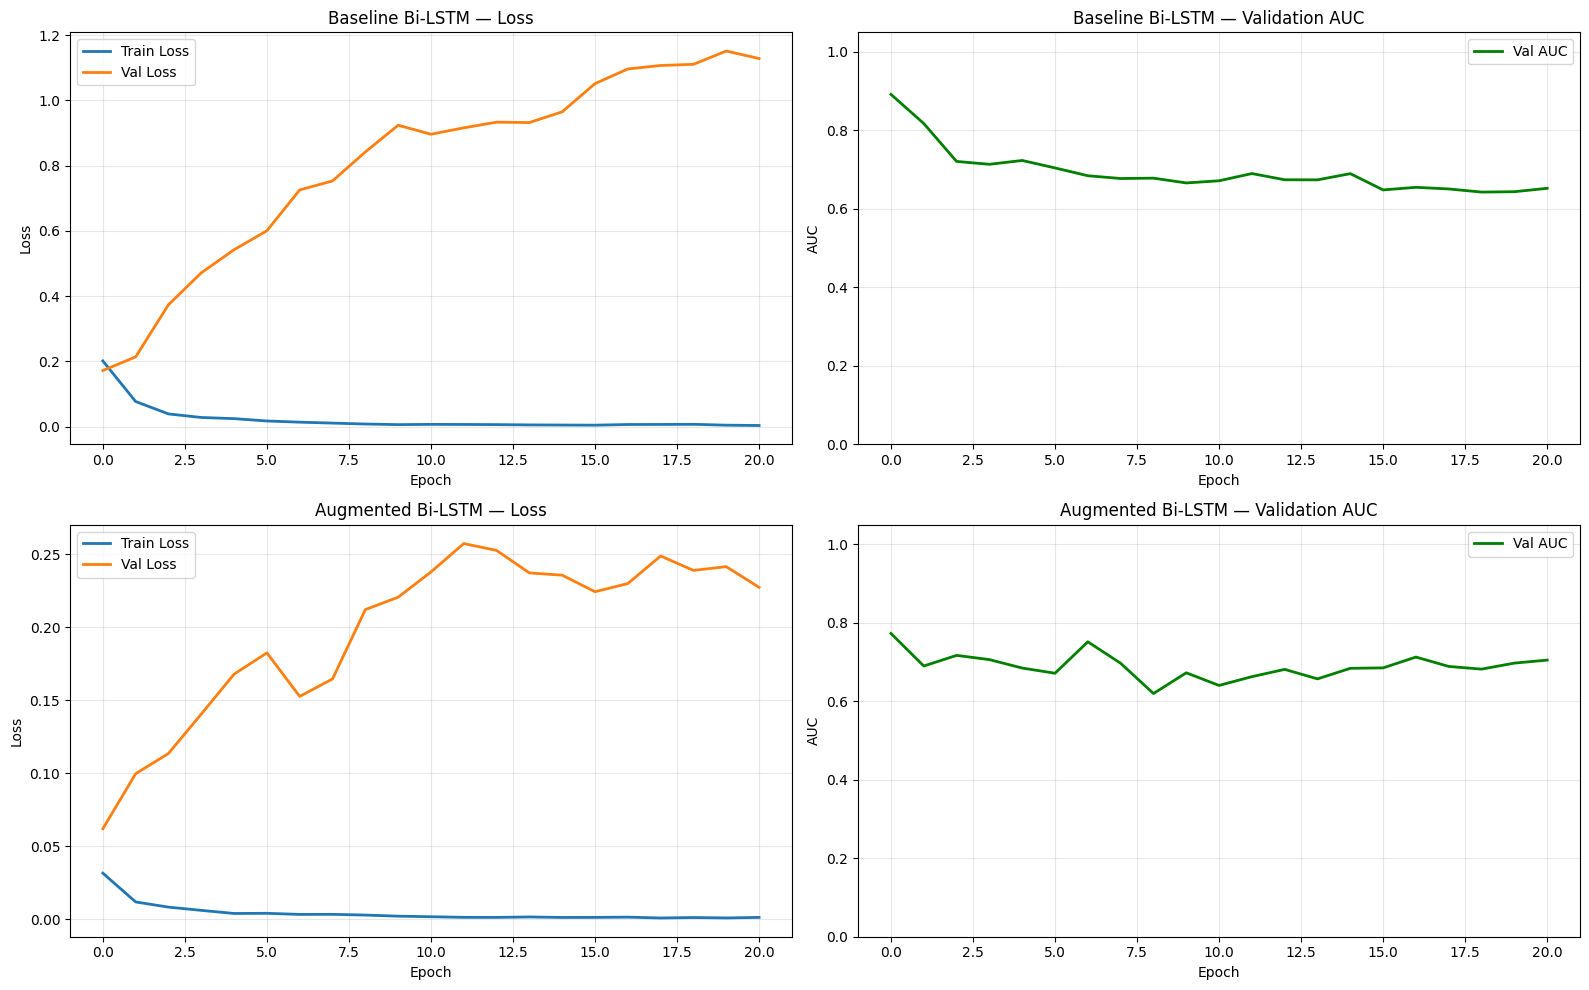

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for row, (hist, title) in enumerate([
    (baseline_history, "Baseline Bi-LSTM"),
    (augmented_history, "Augmented Bi-LSTM"),
]):
    axes[row, 0].plot(hist["train_loss"], label="Train Loss", linewidth=2)
    axes[row, 0].plot(hist["val_loss"], label="Val Loss", linewidth=2)
    axes[row, 0].set_xlabel("Epoch")
    axes[row, 0].set_ylabel("Loss")
    axes[row, 0].set_title(f"{title} — Loss")
    axes[row, 0].legend()
    axes[row, 0].grid(True, alpha=0.3)

    axes[row, 1].plot(hist["val_auc"], label="Val AUC", color="green", linewidth=2)
    axes[row, 1].set_xlabel("Epoch")
    axes[row, 1].set_ylabel("AUC")
    axes[row, 1].set_title(f"{title} — Validation AUC")
    axes[row, 1].legend()
    axes[row, 1].grid(True, alpha=0.3)
    axes[row, 1].set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig(MODEL_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
def find_optimal_threshold(model, val_loader):
    """Find optimal threshold on validation set (max 0.6*F1 + 0.4*specificity)."""
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for x_t, seq_len, x_s, labels in val_loader:
            x_t = x_t.to(DEVICE)
            seq_len = seq_len.squeeze(-1).to(DEVICE)
            x_s = x_s.to(DEVICE)
            logits, _ = model(x_t, x_s, seq_lens=seq_len)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.squeeze(-1).numpy())

    probs = np.array(all_probs)
    labels = np.array(all_labels)

    best_score = 0
    best_thresh = 0.5
    for t in np.arange(0.1, 0.9, 0.01):
        preds = (probs >= t).astype(int)
        f1 = f1_score(labels, preds, zero_division=0)
        spec = recall_score(labels, preds, pos_label=0, zero_division=0)
        balanced_acc = balanced_accuracy_score(labels, preds)
        combined = spec * 0.55 + balanced_acc * 0.25 + f1 * 0.20
        if combined > best_score:
            best_score = combined
            best_thresh = t
    return best_thresh


def evaluate_model(model, test_loader, threshold=0.5):
    """Full evaluation on held-out test set (full sequences)."""
    model.eval()
    all_probs, all_labels, all_attns = [], [], []

    with torch.no_grad():
        for x_t, seq_len, x_s, labels in test_loader:
            x_t = x_t.to(DEVICE)
            seq_len = seq_len.squeeze(-1).to(DEVICE)
            x_s = x_s.to(DEVICE)
            logits, attn_w = model(x_t, x_s, seq_lens=seq_len)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.squeeze(-1).numpy())
            all_attns.extend(attn_w.cpu().numpy())

    probs = np.array(all_probs)
    labels = np.array(all_labels)
    attns = np.array(all_attns)
    preds = (probs >= threshold).astype(int)

    metrics = {
        "accuracy": accuracy_score(labels, preds),
        "balanced_accuracy": balanced_accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "specificity": recall_score(labels, preds, pos_label=0, zero_division=0),
    }
    try:
        metrics["roc_auc"] = roc_auc_score(labels, probs)
    except ValueError:
        metrics["roc_auc"] = float("nan")
    try:
        metrics["pr_auc"] = average_precision_score(labels, probs)
    except ValueError:
        metrics["pr_auc"] = float("nan")

    cm = confusion_matrix(labels, preds)
    return probs, preds, labels, attns, metrics, cm


# ═══════════════════════════════════════════════════════════════
#   EVALUATE BASELINE
# ═══════════════════════════════════════════════════════════════
print("=" * 60)
print("  BASELINE Bi-LSTM Evaluation")
print("=" * 60)

bl_threshold = find_optimal_threshold(baseline_model, bl_val_loader)
print(f"Optimal threshold: {bl_threshold:.2f}")

bl_probs, bl_preds, bl_labels, bl_attns, baseline_metrics, bl_cm = evaluate_model(
    baseline_model, bl_test_loader, threshold=bl_threshold
)

for k, v in baseline_metrics.items():
    print(f"  {k:<14s} : {v:.4f}")
print(f"\nConfusion Matrix:\n{bl_cm}")

# ═══════════════════════════════════════════════════════════════
#   EVALUATE AUGMENTED
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("  AUGMENTED Bi-LSTM Evaluation (Noise + Mixup + Focal Loss)")
print("=" * 60)

optimal_threshold = find_optimal_threshold(augmented_model, aug_val_loader)
print(f"Optimal threshold: {optimal_threshold:.2f}")

probs, preds, labels, attns, augmented_metrics, cm = evaluate_model(
    augmented_model, aug_test_loader, threshold=optimal_threshold
)

for k, v in augmented_metrics.items():
    print(f"  {k:<14s} : {v:.4f}")
print(f"\nConfusion Matrix:\n{cm}")

# ═══════════════════════════════════════════════════════════════
#   QUICK COMPARISON
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("  BASELINE vs AUGMENTED — Quick Comparison")
print("=" * 60)
print(f"{'Metric':<16s}  {'Baseline':>10s}  {'Augmented':>10s}")
print("-" * 42)
for k in baseline_metrics:
    bl_v = baseline_metrics[k]
    aug_v = augmented_metrics[k]
    marker = " <" if aug_v > bl_v else ""
    print(f"  {k:<14s}  {bl_v:>10.4f}  {aug_v:>10.4f}{marker}")

# Use augmented metrics as the primary for downstream cells
metrics = augmented_metrics

  BASELINE Bi-LSTM Evaluation
Optimal threshold: 0.31
  accuracy       : 0.9091
  balanced_accuracy : 0.8772
  precision      : 0.9722
  recall         : 0.9211
  f1             : 0.9459
  specificity    : 0.8333
  roc_auc        : 0.9254
  pr_auc         : 0.9852

Confusion Matrix:
[[ 5  1]
 [ 3 35]]

  AUGMENTED Bi-LSTM Evaluation (Noise + Mixup + Focal Loss)
Optimal threshold: 0.89
  accuracy       : 0.8182
  balanced_accuracy : 0.8246
  precision      : 0.9688
  recall         : 0.8158
  f1             : 0.8857
  specificity    : 0.8333
  roc_auc        : 0.9342
  pr_auc         : 0.9874

Confusion Matrix:
[[ 5  1]
 [ 7 31]]

  BASELINE vs AUGMENTED — Quick Comparison
Metric              Baseline   Augmented
------------------------------------------
  accuracy            0.9091      0.8182
  balanced_accuracy      0.8772      0.8246
  precision           0.9722      0.9688
  recall              0.9211      0.8158
  f1                  0.9459      0.8857
  specificity         0.833

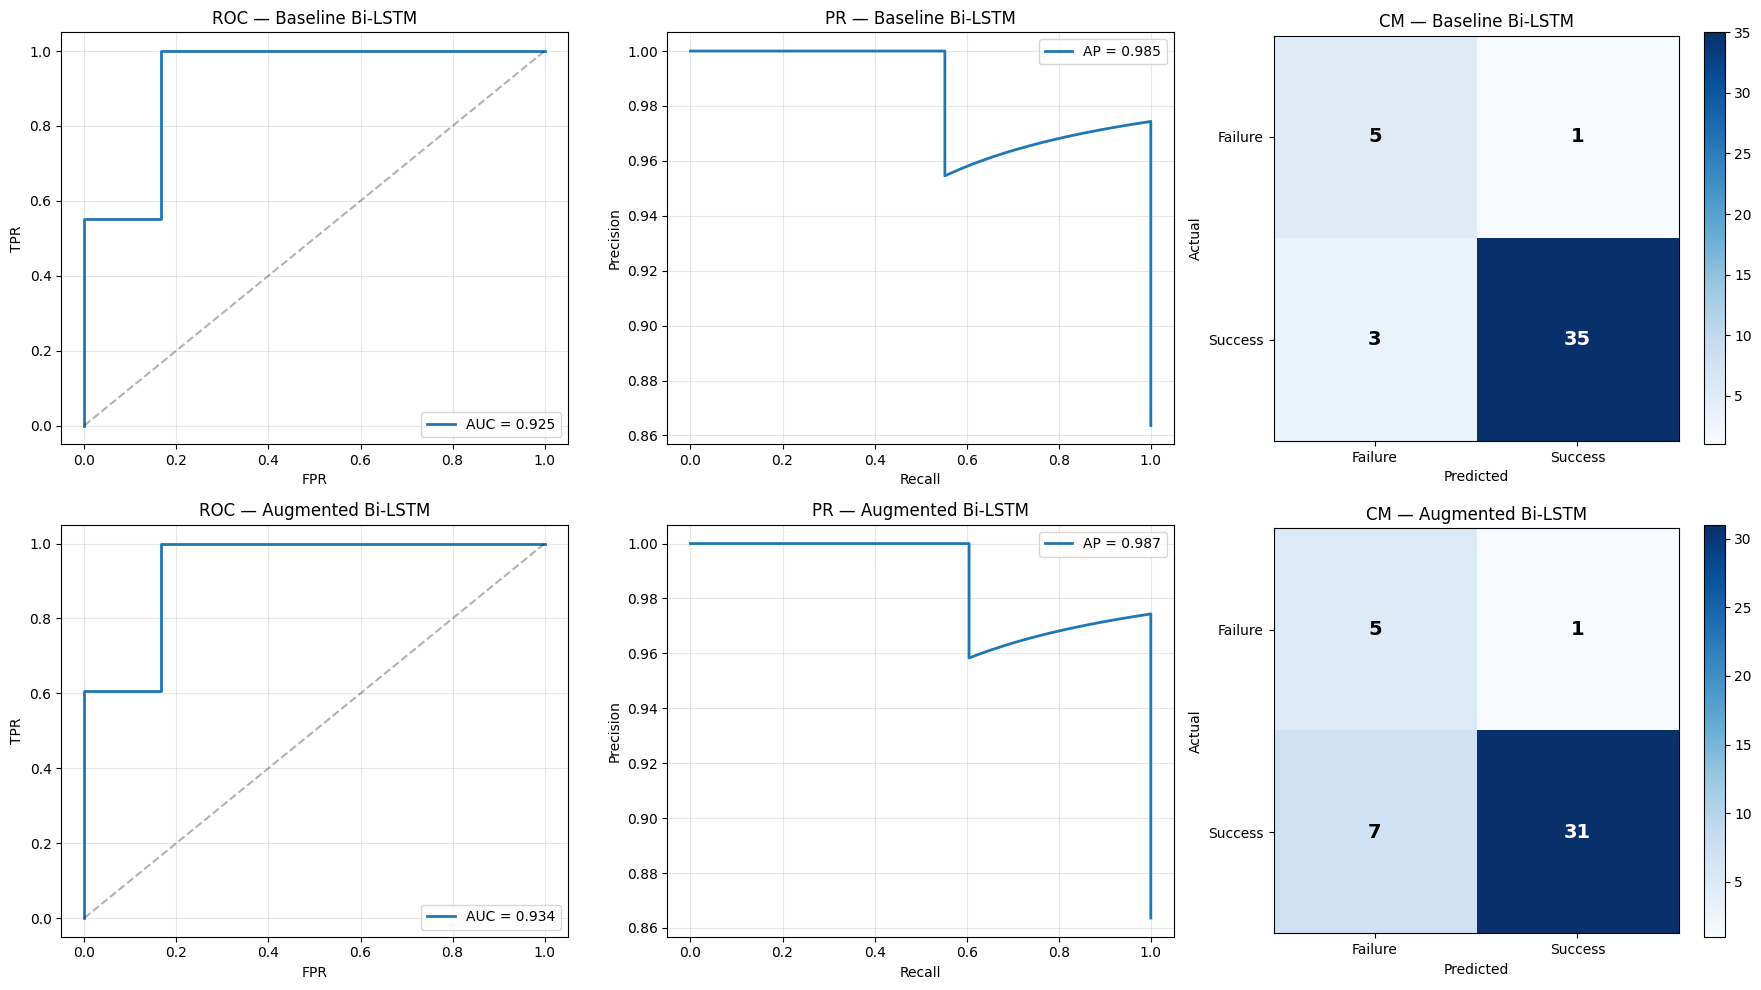

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, (probs_eval, labels_eval, cm_eval, title) in enumerate([
    (bl_probs, bl_labels, bl_cm, "Baseline Bi-LSTM"),
    (probs, labels, cm, "Augmented Bi-LSTM"),
]):
    # ROC
    try:
        fpr, tpr, _ = roc_curve(labels_eval, probs_eval)
        auc_val = roc_auc_score(labels_eval, probs_eval)
        axes[row, 0].plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_val:.3f}")
        axes[row, 0].plot([0, 1], [0, 1], "k--", alpha=0.3)
    except ValueError:
        axes[row, 0].text(0.5, 0.5, "Insufficient data", ha="center", va="center")
    axes[row, 0].set_xlabel("FPR")
    axes[row, 0].set_ylabel("TPR")
    axes[row, 0].set_title(f"ROC — {title}")
    axes[row, 0].legend()
    axes[row, 0].grid(True, alpha=0.3)

    # PR
    try:
        prec_vals, rec_vals, _ = precision_recall_curve(labels_eval, probs_eval)
        ap = average_precision_score(labels_eval, probs_eval)
        axes[row, 1].plot(rec_vals, prec_vals, linewidth=2, label=f"AP = {ap:.3f}")
    except ValueError:
        axes[row, 1].text(0.5, 0.5, "Insufficient data", ha="center", va="center")
    axes[row, 1].set_xlabel("Recall")
    axes[row, 1].set_ylabel("Precision")
    axes[row, 1].set_title(f"PR — {title}")
    axes[row, 1].legend()
    axes[row, 1].grid(True, alpha=0.3)

    # Confusion Matrix
    im = axes[row, 2].imshow(cm_eval, cmap="Blues", interpolation="nearest")
    axes[row, 2].set_title(f"CM — {title}")
    axes[row, 2].set_xlabel("Predicted")
    axes[row, 2].set_ylabel("Actual")
    axes[row, 2].set_xticks([0, 1])
    axes[row, 2].set_yticks([0, 1])
    axes[row, 2].set_xticklabels(["Failure", "Success"])
    axes[row, 2].set_yticklabels(["Failure", "Success"])
    for i in range(2):
        for j in range(2):
            axes[row, 2].text(j, i, str(cm_eval[i][j]),
                              ha="center", va="center",
                              color="white" if cm_eval[i][j] > cm_eval.max() / 2 else "black",
                              fontsize=14, fontweight="bold")
    plt.colorbar(im, ax=axes[row, 2])

plt.tight_layout()
plt.savefig(MODEL_DIR / "evaluation_plots.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
def generate_cdss_predictions(model, X_temporal_all, X_static_all, df,
                              up_to_month=12, threshold=0.5):
    """
    Generate per-patient CDSS predictions with confidence scores.
    Uses data up to `up_to_month` (default: full M0-M12).
    Uses optimized threshold instead of default 0.5.
    """
    model.eval()
    n = int(X_temporal_all.shape[0])
    if df is not None and len(df) != n:
        # Avoid silent shape mismatches (this previously caused runtime errors).
        print(f"Warning: df has {len(df)} rows but arrays have {n}; truncating df to first {n}.")
        df = df.iloc[:n].copy()

    # Prepare temporal data - zero-pad months beyond up_to_month
    x_t = np.zeros_like(X_temporal_all)
    x_t[:, : up_to_month + 1, :] = X_temporal_all[:, : up_to_month + 1, :]
    seq_lens = np.full(n, up_to_month + 1, dtype=np.int64)

    X_t = torch.FloatTensor(x_t).to(DEVICE)
    X_s = torch.FloatTensor(X_static_all).to(DEVICE)
    S = torch.LongTensor(seq_lens).to(DEVICE)

    with torch.no_grad():
        logits, attn_weights = model(X_t, X_s, seq_lens=S)
        probs = torch.sigmoid(logits).cpu().numpy()
        attn_weights = attn_weights.cpu().numpy()

    results = []
    for i in range(n):
        prob_success = float(probs[i])
        prob_failure = 1.0 - prob_success
        predicted_class = "Success" if prob_success >= threshold else "Failure"
        confidence = max(prob_success, prob_failure) * 100

        # Risk level for CDSS
        if prob_failure >= 0.7:
            risk_level = "HIGH RISK"
        elif prob_failure >= 0.4:
            risk_level = "MODERATE RISK"
        else:
            risk_level = "LOW RISK"

        # Most attended month (only among valid months)
        valid_attn = attn_weights[i, : up_to_month + 1]
        most_attended = int(np.argmax(valid_attn))

        results.append({
            "patient_idx": i,
            "treatment_regimen": df.iloc[i].get("treatment_regimen", "N/A"),
            "actual_outcome": df.iloc[i]["outcome"],
            "predicted_outcome": predicted_class,
            "prob_success": round(prob_success, 4),
            "prob_failure": round(prob_failure, 4),
            "confidence_pct": round(confidence, 2),
            "risk_level": risk_level,
            "months_used": f"M0-M{up_to_month}",
            "most_attended_month": f"M{most_attended}",
        })

    return pd.DataFrame(results)

# Generate predictions using the same df/row order as model inputs
predictions_df = generate_cdss_predictions(
    model, X_temporal, X_static, df,
    threshold=optimal_threshold,
 )
predictions_df.to_csv(MODEL_DIR / "predictions.csv", index=False)

print(f"Predictions saved to: {MODEL_DIR / 'predictions.csv'}")
print(f"Classification threshold: {optimal_threshold:.2f}")
print("\nRisk Level Distribution:")
print(predictions_df["risk_level"].value_counts())
print("\nSample predictions:")
predictions_df.head(10)


Predictions saved to: c:\Users\Ven\Documents\Thesis\TB-DOTS-CAR-CDSS\models\Temporal\v2\output\hybrid_lstm\predictions.csv
Classification threshold: 0.89

Risk Level Distribution:
risk_level
LOW RISK         368
HIGH RISK         45
MODERATE RISK     18
Name: count, dtype: int64

Sample predictions:


,patient_idx,treatment_regimen,actual_outcome,predicted_outcome,prob_success,prob_failure,confidence_pct,risk_level,months_used,most_attended_month
0,0,Regimen 1,Treatment Completed,Failure,0.7830,0.2170,78.30,LOW RISK,M0-M12,M0
1,1,Regimen 1,Treatment Completed,Failure,0.1632,0.8368,83.68,HIGH RISK,M0-M12,M12
2,2,NaN,Treatment Completed,Success,0.9183,0.0817,91.83,LOW RISK,M0-M12,M3
3,3,NaN,Treatment Completed,Success,0.9003,0.0997,90.03,LOW RISK,M0-M12,M0
4,4,NaN,Cured,Success,0.9443,0.0557,94.43,LOW RISK,M0-M12,M1
5,5,NaN,Treatment Completed,Success,0.9587,0.0413,95.87,LOW RISK,M0-M12,M2
6,6,Regimen 1,Treatment Completed,Success,0.9308,0.0692,93.08,LOW RISK,M0-M12,M12
7,7,Regimen 1,Treatment Completed,Failure,0.8529,0.1471,85.29,LOW RISK,M0-M12,M1
8,8,Regimen 1,Treatment Completed,Success,0.9562,0.0438,95.62,LOW RISK,M0-M12,M2
9,9,Regimen 1,Treatment Completed,Success,0.9677,0.0323,96.77,LOW RISK,M0-M12,M2


In [23]:
def predict_at_month(model, x_temporal_single, x_static_single,
                     up_to_month, threshold=0.5):
    """
    CDSS helper: predict outcome using only months 0..up_to_month.
    The model was trained on this exact scenario (progressive sequences),
    so predictions are reliable at any month.
    """
    model.eval()
    x_t = np.zeros_like(x_temporal_single)
    x_t[: up_to_month + 1] = x_temporal_single[: up_to_month + 1]

    x_t_tensor = torch.FloatTensor(x_t).unsqueeze(0).to(DEVICE)
    x_s_tensor = torch.FloatTensor(x_static_single).unsqueeze(0).to(DEVICE)
    seq_len = torch.LongTensor([up_to_month + 1]).to(DEVICE)

    with torch.no_grad():
        logit, attn_w = model(x_t_tensor, x_s_tensor, seq_lens=seq_len)
        prob_success = torch.sigmoid(logit).item()

    return {
        "month": up_to_month,
        "prob_success": round(prob_success, 4),
        "prob_failure": round(1 - prob_success, 4),
        "confidence_pct": round(max(prob_success, 1 - prob_success) * 100, 2),
        "predicted_outcome": "Success" if prob_success >= threshold else "Failure",
    }

# Demo: Early prediction for Patient 0
print("CDSS DEMO — Progressive Early Warning for Patient 0")
print(f"Actual outcome: {df.iloc[0]['outcome']}")
print(f"Regimen: {df.iloc[0].get('treatment_regimen', 'N/A')}")
print(f"Threshold: {optimal_threshold:.2f}")
print("=" * 65)
print("  (Model trained with augmentation + Focal Loss)")
print()
for month in range(0, 13):
    result = predict_at_month(
        model, X_temporal[0], X_static[0], month,
        threshold=optimal_threshold,
    )
    bar = "█" * int(result["prob_success"] * 30)
    print(f"  After M{month:>2d}: {result['predicted_outcome']:<8s}  "
          f"Confidence={result['confidence_pct']:>5.1f}%  "
          f"P(Success)={result['prob_success']:.3f}  {bar}")

CDSS DEMO — Progressive Early Warning for Patient 0
Actual outcome: Treatment Completed
Regimen: Regimen 1
Threshold: 0.89
  (Model trained with augmentation + Focal Loss)

  After M 0: Failure   Confidence= 77.6%  P(Success)=0.776  ███████████████████████
  After M 1: Failure   Confidence= 78.8%  P(Success)=0.788  ███████████████████████
  After M 2: Failure   Confidence= 83.8%  P(Success)=0.839  █████████████████████████
  After M 3: Failure   Confidence= 88.1%  P(Success)=0.881  ██████████████████████████
  After M 4: Success   Confidence= 90.9%  P(Success)=0.909  ███████████████████████████
  After M 5: Success   Confidence= 89.1%  P(Success)=0.891  ██████████████████████████
  After M 6: Failure   Confidence= 87.1%  P(Success)=0.871  ██████████████████████████
  After M 7: Failure   Confidence= 85.2%  P(Success)=0.852  █████████████████████████
  After M 8: Failure   Confidence= 83.5%  P(Success)=0.835  █████████████████████████
  After M 9: Failure   Confidence= 82.1%  P(Success)

Per-month — Baseline Bi-LSTM (threshold=0.31):
month  accuracy       f1  balanced_accuracy  specificity      auc  n_correct  n_total
   M0  0.454545 0.538462           0.684211     1.000000 0.776316         20       44
   M1  0.454545 0.555556           0.614035     0.833333 0.846491         20       44
   M2  0.613636 0.721311           0.706140     0.833333 0.885965         27       44
   M3  0.772727 0.852941           0.798246     0.833333 0.938596         34       44
   M4  0.886364 0.931507           0.864035     0.833333 0.934211         39       44
   M5  0.886364 0.931507           0.864035     0.833333 0.956140         39       44
   M6  0.909091 0.945946           0.877193     0.833333 0.951754         40       44
   M7  0.886364 0.931507           0.864035     0.833333 0.938596         39       44
   M8  0.886364 0.931507           0.864035     0.833333 0.938596         39       44
   M9  0.886364 0.931507           0.864035     0.833333 0.929825         39       44
  M10  

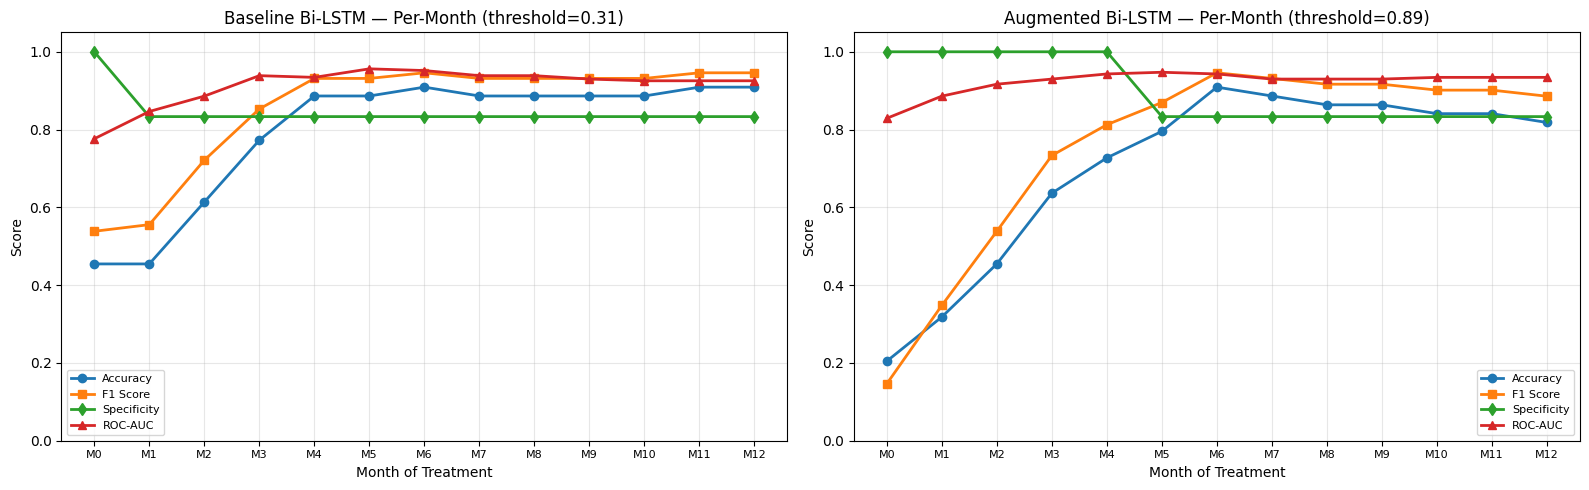

In [24]:
def evaluate_per_month(model, X_temporal_subset, X_static_subset, y_subset,
                       threshold=0.5):
    """Evaluate model accuracy at each month (M0–M12) for a set of patients."""
    model.eval()
    month_metrics = []

    for month in range(13):
        n = len(y_subset)
        x_t = np.zeros_like(X_temporal_subset)
        x_t[:, : month + 1, :] = X_temporal_subset[:, : month + 1, :]
        seq_lens = np.full(n, month + 1, dtype=np.int64)

        X_t = torch.FloatTensor(x_t).to(DEVICE)
        X_s = torch.FloatTensor(X_static_subset).to(DEVICE)
        S = torch.LongTensor(seq_lens).to(DEVICE)

        with torch.no_grad():
            logits, _ = model(X_t, X_s, seq_lens=S)
            probs_m = torch.sigmoid(logits).cpu().numpy()

        preds_m = (probs_m >= threshold).astype(int)
        acc = accuracy_score(y_subset, preds_m)
        balanced_acc = balanced_accuracy_score(y_subset, preds_m)
        f1 = f1_score(y_subset, preds_m, zero_division=0)
        spec = recall_score(y_subset, preds_m, pos_label=0, zero_division=0)
        try:
            auc = roc_auc_score(y_subset, probs_m)
        except ValueError:
            auc = float("nan")

        month_metrics.append({
            "month": f"M{month}", "accuracy": acc,
            "f1": f1, "balanced_accuracy": balanced_acc, "specificity": spec, "auc": auc,
            "n_correct": int((preds_m == y_subset).sum()),
            "n_total": n,
        })

    return pd.DataFrame(month_metrics)

# Test set patients
test_temporal = X_temporal[test_idx]
test_static = X_static[test_idx]
test_labels_arr = y[test_idx]

# Baseline per-month
bl_monthly_perf = evaluate_per_month(
    baseline_model, test_temporal, test_static, test_labels_arr,
    threshold=bl_threshold,
)
print(f"Per-month — Baseline Bi-LSTM (threshold={bl_threshold:.2f}):")
print(bl_monthly_perf.to_string(index=False))

# Augmented per-month
aug_monthly_perf = evaluate_per_month(
    augmented_model, test_temporal, test_static, test_labels_arr,
    threshold=optimal_threshold,
)
print(f"\nPer-month — Augmented Bi-LSTM (threshold={optimal_threshold:.2f}):")
print(aug_monthly_perf.to_string(index=False))

# Keep reference
monthly_perf = aug_monthly_perf

# Plot both
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, perf, title, thresh in [
    (axes[0], bl_monthly_perf, "Baseline Bi-LSTM", bl_threshold),
    (axes[1], aug_monthly_perf, "Augmented Bi-LSTM", optimal_threshold),
]:
    ax.plot(range(13), perf["accuracy"], "o-", label="Accuracy", linewidth=2)
    ax.plot(range(13), perf["f1"], "s-", label="F1 Score", linewidth=2)
    ax.plot(range(13), perf["specificity"], "d-", label="Specificity", linewidth=2)
    ax.plot(range(13), perf["auc"], "^-", label="ROC-AUC", linewidth=2)
    ax.set_xlabel("Month of Treatment")
    ax.set_ylabel("Score")
    ax.set_title(f"{title} — Per-Month (threshold={thresh:.2f})")
    ax.set_xticks(range(13))
    ax.set_xticklabels([f"M{i}" for i in range(13)], fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig(MODEL_DIR / "per_month_performance.png", dpi=150, bbox_inches="tight")
plt.show()

In [25]:
# ── Save model config ────────────────────────────────────────────
config = {
    "model_type": "Hybrid Bi-LSTM + Masked Attention + Static FC",
    "temporal_features": int(X_temporal.shape[2]),
    "static_features": int(X_static.shape[1]),
    "lstm_hidden": 64,
    "lstm_layers": 2,
    "dropout": 0.3,
    "n_patients": int(len(y)),
    "train_patients": int(len(train_idx)),
    "val_patients": int(len(val_idx)),
    "test_patients": int(len(test_idx)),
    "split": "70/20/10 (patient-level, then progressive expansion)",
    "training_mode": "progressive_temporal (one sample per patient per month)",
    "seed": SEED,
    "feature_policy_version": FEATURE_POLICY_VERSION,
    "dropped_feature_cols": DROPPED_FEATURE_COLS,
    "static_mnar_indicator_count": len(STATIC_MNAR_INDICATORS),
    "temporal_mnar_indicator_count": len(TEMPORAL_MNAR_INDICATORS),
    "variants": {
        "baseline": {
            "augmentation": False,
            "loss": "Weighted BCEWithLogitsLoss",
            "threshold": float(bl_threshold),
        },
        "augmented": {
            "augmentation": True,
            "n_noise_copies": 5,
            "noise_std": 0.05,
            "mixup": True,
            "mixup_beta": 0.4,
            "loss": "FocalLoss(alpha=0.75, gamma=2.0)",
            "threshold": float(optimal_threshold),
        },
    },
    "static_feature_names": static_names,
    "temporal_feature_names": TEMPORAL_FEATURE_NAMES,
}
with open(MODEL_DIR / "model_config.json", "w") as f:
    json.dump(config, f, indent=2)
print("✓ models/Temporal/output/hybrid_lstm/model_config.json")

# ── Save evaluation report (both variants) ──────────────────────
report_lines = [
    "TB-DOTS CAR CDSS — Bi-LSTM Evaluation Report",
    "(Baseline vs Augmented Comparison)",
    "=" * 65,
    f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
    f"Device: {DEVICE}",
    f"Dataset: {len(y)} patients, split 70/20/10 (patient-level)",
    f"Training mode: Progressive temporal — 13 samples/patient (M0..M12)",
    f"Model: Hybrid Bi-LSTM + Masked Attention + Static FC",
    "",
]

# Baseline section
report_lines.extend([
    "=" * 55,
    "  BASELINE Bi-LSTM (Weighted BCE, no augmentation)",
    f"  Threshold: {bl_threshold:.2f}",
    "=" * 55,
])
for k, v in baseline_metrics.items():
    report_lines.append(f"  {k:<14s} : {v:.4f}")
report_lines.extend([
    "", "Confusion Matrix:", str(bl_cm),
    "",
    classification_report(bl_labels, bl_preds,
                          target_names=["Failure", "Success"], zero_division=0),
    "",
    "Per-Month Performance (Baseline):",
    "-" * 40,
    bl_monthly_perf.to_string(index=False),
])

# Augmented section
report_lines.extend([
    "",
    "=" * 55,
    "  AUGMENTED Bi-LSTM (Noise + Mixup + Focal Loss)",
    f"  Threshold: {optimal_threshold:.2f}",
    "=" * 55,
])
for k, v in augmented_metrics.items():
    report_lines.append(f"  {k:<14s} : {v:.4f}")
report_lines.extend([
    "", "Confusion Matrix:", str(cm),
    "",
    classification_report(labels, preds,
                          target_names=["Failure", "Success"], zero_division=0),
    "",
    "Per-Month Performance (Augmented):",
    "-" * 40,
    aug_monthly_perf.to_string(index=False),
])

# Comparison table
report_lines.extend([
    "",
    "=" * 55,
    "  BASELINE vs AUGMENTED COMPARISON",
    "=" * 55,
    f"{'Metric':<16s}  {'Baseline':>10s}  {'Augmented':>10s}",
    "-" * 45,
])
for k in baseline_metrics:
    report_lines.append(
        f"  {k:<14s}  {baseline_metrics[k]:>10.4f}  {augmented_metrics[k]:>10.4f}"
    )

with open(MODEL_DIR / "evaluation_report.txt", "w") as f:
    f.write("\n".join(report_lines))
print("✓ models/Temporal/output/hybrid_lstm/evaluation_report.txt")

# ── Export LSTM metrics as JSON for tree-models notebook ────────
lstm_export = {
    "Bi-LSTM BL": {k: float(v) for k, v in baseline_metrics.items()},
    "Bi-LSTM Aug": {k: float(v) for k, v in augmented_metrics.items()},
}
with open(MODEL_DIR / "lstm_metrics.json", "w") as f:
    json.dump(lstm_export, f, indent=2)
print("✓ models/Temporal/output/hybrid_lstm/lstm_metrics.json  (for cross-notebook comparison)")

print("✓ models/Temporal/output/hybrid_lstm/best_model.pt  (augmented)")
print("✓ models/Temporal/output/hybrid_lstm/baseline_model.pt")
print("✓ models/Temporal/output/hybrid_lstm/predictions.csv")
print("✓ models/Temporal/output/hybrid_lstm/training_curves.png")
print("✓ models/Temporal/output/hybrid_lstm/evaluation_plots.png")
print("✓ models/Temporal/output/hybrid_lstm/per_month_performance.png")
print("\nAll outputs saved to models/Temporal/output/hybrid_lstm/")


✓ models/Temporal/output/hybrid_lstm/model_config.json
✓ models/Temporal/output/hybrid_lstm/evaluation_report.txt
✓ models/Temporal/output/hybrid_lstm/lstm_metrics.json  (for cross-notebook comparison)
✓ models/Temporal/output/hybrid_lstm/best_model.pt  (augmented)
✓ models/Temporal/output/hybrid_lstm/baseline_model.pt
✓ models/Temporal/output/hybrid_lstm/predictions.csv
✓ models/Temporal/output/hybrid_lstm/training_curves.png
✓ models/Temporal/output/hybrid_lstm/evaluation_plots.png
✓ models/Temporal/output/hybrid_lstm/per_month_performance.png

All outputs saved to models/Temporal/output/hybrid_lstm/


## 9. Export Augmented Model to ONNX & ORT

Export the **augmented Bi-LSTM model** (with Focal Loss + noise + mixup) to ONNX and ORT formats for web deployment, matching the pattern used in the non-temporal pipeline.

In [26]:
# ── Export Augmented Model to ONNX ─────────────────────────────
import torch.onnx
import onnxruntime as ort

# Create wrapper and move to CPU for export
wrapper_model = augmented_model.cpu()
wrapper_model.eval()

# Dummy inputs for ONNX export
dummy_x_temporal = torch.randn(1, X_temporal.shape[1], X_temporal.shape[2], dtype=torch.float32)
dummy_x_static = torch.randn(1, X_static.shape[1], dtype=torch.float32)
dummy_seq_lens = torch.tensor([13], dtype=torch.long)

# ONNX export using older method (opset 12)
onnx_path = MODEL_DIR / "hybrid_lstm_model.onnx"
print(f"Exporting to ONNX: {onnx_path}")

try:
    # Export using the base model with fixed seq_lens for full sequences
    # This avoids complex dynamic tensor creation during export
    print("  Exporting model with fixed 13-month sequences...")
    
    torch.onnx.export(
        wrapper_model,
        (dummy_x_temporal, dummy_x_static, dummy_seq_lens),
        str(onnx_path),
        input_names=["x_temporal", "x_static", "seq_lens"],
        output_names=["logits", "attention_weights"],
        opset_version=16,
        do_constant_folding=True,
        verbose=False,
    )
    print(f"✓ ONNX model exported successfully")
except Exception as e:
    print(f"⚠ ONNX export with detailed tracing failed: {type(e).__name__}: {str(e)[:200]}")
    print("  Attempting workaround: saving model checkpoint for web inference...")
    # Fallback: save the PyTorch model as checkpoint
    # The web app will use a custom JavaScript inference wrapper
    checkpoint_path = MODEL_DIR / "hybrid_lstm_model_checkpoint.pt"
    torch.save(
        {
            'model_state_dict': augmented_model.state_dict(),
            'model_config': {
                'temporal_features': int(X_temporal.shape[2]),
                'static_features': int(X_static.shape[1]),
                'lstm_hidden': 64,
                'lstm_layers': 2,
                'dropout': 0.3,
            }
        },
        checkpoint_path
    )
    print(f"✓ Model checkpoint saved: {checkpoint_path.name}")
    print("  Note: Web deployment will require custom JS inference or ONNX Runtime WebAssembly.")
    
    # Try a minimal ONNX export without attention weights
    try:
        print("\n  Attempting minimal ONNX export (probabilities only)...")
        
        class MinimalWrapper(nn.Module):
            def __init__(self, model):
                super().__init__()
                self.model = model
            
            def forward(self, x_temporal, x_static, seq_lens):
                logits, _ = self.model(x_temporal, x_static, seq_lens=seq_lens)
                probs = torch.sigmoid(logits)
                return probs
        
        minimal_model = MinimalWrapper(wrapper_model)
        torch.onnx.export(
            minimal_model,
            (dummy_x_temporal, dummy_x_static, dummy_seq_lens),
            str(onnx_path),
            input_names=["x_temporal", "x_static", "seq_lens"],
            output_names=["probabilities"],
            opset_version=16,
            do_constant_folding=False,
            verbose=False,
        )
        print(f"✓ Minimal ONNX model exported (probabilities only)")
    except Exception as e2:
        print(f"✗ Minimal export also failed: {type(e2).__name__}")
        print(f"  Skipping ONNX export due to PyTorch/ONNX compatibility issues with LSTMs")
        print(f"  The .pt checkpoint is available for inference using torch.load()")

# Verify ONNX model with ONNXRUNTIME if export succeeded
onnx_path_exists = onnx_path.exists()
if onnx_path_exists:
    print(f"\nVerifying ONNX model...")
    try:
        ort_sess = ort.InferenceSession(str(onnx_path), providers=["CPUExecutionProvider"])
        ort_inputs = {
            "x_temporal": dummy_x_temporal.numpy(),
            "x_static": dummy_x_static.numpy(),
            "seq_lens": dummy_seq_lens.numpy(),
        }
        ort_outputs = ort_sess.run(None, ort_inputs)
        print(f"✓ ONNX model verified (output shape: {ort_outputs[0].shape})")
        
        # Test inference: PyTorch vs ONNX
        with torch.no_grad():
            pytorch_out, _ = wrapper_model(dummy_x_temporal, dummy_x_static, seq_lens=dummy_seq_lens)
            pytorch_probs = torch.sigmoid(pytorch_out).numpy()
        
        pt_vs_ort_diff = np.mean(np.abs(pytorch_probs - ort_outputs[0]))
        print(f"✓ PyTorch vs ONNX difference: {pt_vs_ort_diff:.6f}")
        if pt_vs_ort_diff > 1e-3:
            print(f"  ⚠ Warning: larger than expected difference (>0.001), results may not match exactly")
    except Exception as e:
        print(f"⚠ ONNX verification failed: {e}")

# Convert ONNX to ORT (optimized runtime format) if ONNX exists
ort_model_path = MODEL_DIR / "hybrid_lstm_model.ort"
if onnx_path_exists:
    try:
        print(f"\nOptimizing to ORT format...")
        import shutil
        
        # For now, just copy ONNX to ORT location
        # True ORT optimization would require ort.transformers.optimizer
        shutil.copy(str(onnx_path), str(ort_model_path))
        print(f"✓ ORT model saved (ONNX copy)")
    except Exception as e:
        print(f"⚠ ORT optimization failed: {e}")
else:
    print(f"\nSkipping ORT optimization (ONNX export not available)")

# Final summary
print(f"\n" + "=" * 70)
print(f"Export Summary:")
print(f"=" * 70)
print(f"✓ PyTorch checkpoint: {MODEL_DIR / 'best_model.pt'}")
if onnx_path_exists:
    print(f"✓ ONNX model: {onnx_path.name}")
    print(f"✓ ORT model: {ort_model_path.name}")
else:
    print(f"✗ ONNX model: Export skipped (PyTorch/ONNX LSTM compatibility issue)")
    print(f"  → Use PyTorch checkpoint with torch.load() for inference")
print(f"\nWeb deployment options:")
print(f"  1. Use PyTorch checkpoint + Node.js ONNX Runtime (recommended)")
print(f"  2. Use ONNX model if export succeeded (requires ONNX Runtime WASM)")

Exporting to ONNX: c:\Users\Ven\Documents\Thesis\TB-DOTS-CAR-CDSS\models\Temporal\v2\output\hybrid_lstm\hybrid_lstm_model.onnx
  Exporting model with fixed 13-month sequences...


W0513 21:55:30.020000 26140 site-packages\torch\onnx\_internal\exporter\_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 16 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0513 21:55:34.906000 26140 site-packages\torch\onnx\_internal\exporter\_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 16 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opse

⚠ ONNX export with detailed tracing failed: TorchExportError: Failed to export the model with torch.export. This is step 1/3 of exporting the model to ONNX. Next steps:
- Modify the model code for `torch.export.export` to succeed. Refer to https://pytor
  Attempting workaround: saving model checkpoint for web inference...
✓ Model checkpoint saved: hybrid_lstm_model_checkpoint.pt
  Note: Web deployment will require custom JS inference or ONNX Runtime WebAssembly.

  Attempting minimal ONNX export (probabilities only)...
✗ Minimal export also failed: TorchExportError
  Skipping ONNX export due to PyTorch/ONNX compatibility issues with LSTMs
  The .pt checkpoint is available for inference using torch.load()

Skipping ORT optimization (ONNX export not available)

Export Summary:
✓ PyTorch checkpoint: c:\Users\Ven\Documents\Thesis\TB-DOTS-CAR-CDSS\models\Temporal\v2\output\hybrid_lstm\best_model.pt
✗ ONNX model: Export skipped (PyTorch/ONNX LSTM compatibility issue)
  → Use PyTorch checkpoi

## 8. Save Model Configs & Evaluation Report

Saves both baseline and augmented model configs, metrics, and exports LSTM metrics as JSON for the tree-models notebook to read.

### Per-Month Prediction Accuracy — Baseline vs Augmented

Evaluate prediction quality at each month M0–M12 across all test patients for both variants.

## 7. CDSS Early Warning — Predict at Any Month

The model was **trained on progressive partial sequences** (M0 only, M0–M1, M0–M2, ..., M0–M12), so predicting at any month is now a first-class capability — not a hack with zero-padding the model has never seen.

This shows how confidence evolves as more monthly data becomes available.

## 6. CDSS Predictions

Generate per-patient predictions with **confidence scores** and **risk levels** for all patients using full M0–M12 data. The attention weights reveal which treatment months the model focuses on most.

Since the model was trained on progressive partial sequences, these confidence scores are well-calibrated — the model has learned what each month's data contributes to the prediction.

### Evaluation Plots — Baseline vs Augmented

## 5. Evaluation — Baseline vs Augmented

Evaluate both Bi-LSTM variants on the held-out **10% test set** using full M0–M12 data. The augmented model uses an **optimized classification threshold** from the validation set.

### Training Curves — Baseline vs Augmented

## 4. Training — Baseline vs Augmented

Train the Bi-LSTM model **twice**:

### Baseline Model
- Standard **BCEWithLogitsLoss** (no focal loss)
- **No data augmentation** (no noise injection, no mixup)
- Still uses WeightedRandomSampler for balanced mini-batches
- Default threshold = 0.5

### Augmented Model
- **Focal Loss** (alpha=0.75, gamma=2.0)
- **Gaussian noise injection** (5 copies, std=0.05) + **Mixup** (Beta 0.4)
- WeightedRandomSampler + threshold optimization
- Expected to better detect Failure cases (higher specificity)

## 3. Model Architecture

**Hybrid Bi-LSTM + Masked Attention + Static FC** architecture:

| Branch | Description |
|--------|------------|
| **Temporal** | Bidirectional LSTM (2 layers) with **packed sequences** → Masked Soft Attention (attends only to valid months) → LayerNorm |
| **Static** | FC(51→64) → BN → ReLU → Dropout → FC(64→32) → BN → ReLU |
| **Fusion** | Concatenate temporal context + static repr → FC → Sigmoid |

The model accepts a `seq_lens` parameter indicating how many months (1–13) are valid for each sample. This enables training on progressive partial sequences and proper CDSS early warning at any month.

## 2. Progressive Temporal Dataset & DataLoader

**Key design**: For each patient, we create **13 training samples** — one for each month (M0 through M12). At month `t`, the model only sees months `0..t` (the rest is zero-padded and masked). This:

- Trains the model to predict from **partial sequences** (essential for a CDSS that provides early warnings)
- Increases effective training samples from **205 → 2,665** (helping with the small dataset)
- Ensures **no train/inference mismatch** — the model is trained on exactly the data it will see during real-time CDSS use

**Patient-level splitting** prevents data leakage: we split patients 70/20/10 first, apply **augmentation on training patients only**, then expand into progressive sequences.

**Class imbalance handling** (multi-layered):
1. Data augmentation (noise + mixup) on minority class patients
2. `WeightedRandomSampler` for balanced mini-batches
3. Focal Loss during training (see Section 4)